<h1 style="text-align:center">
    Movies
</h1>

<br>

<font color="darkblue">

<h3 style="text-align:center">
    Luis Pozuelos Juarez
</h3>
    
<h3 style="text-align:center">
    2025-03-10
</h3>

<hr>

# Introducción

<br>

En este proyecto se desarrolla en Python un análisis básico de datos sobre películas de cine de IMDB.
El set de datos que vamos a usar inicialmente se encuentra en la siguiente página:

https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset

En ella puede encontrarse información más detallada, así como una descripción precisa de cada columna.

<font color="green">
Seguidamente, te toca a ti hacer una breve introducción, completando el fragmento de letra en azul y desarrollándolo a tu antojo. Suprime después este fragmento en verde.
</font>

<br>

Se plantean los apartados iniciales para su resolución *sin usar la libreria pandas*. Esto se propone así para forzar a practicar con las técnicas, herramientas y conceptos básicos de Python. Más adelante, hay otros apartados propuestos para su resolución con esta librería y otras.

<br>

<font color="darkblue">
A partir de los datos proporcionados, he conseguido ... pero no he podido ...

<br>

Aunque al final de este notebook detallaré la calificación que calculo honestamente, globalmente, siguiendo las puntuaciones que se asigna a cada apartado, diría que he obtenido una nota de *** sobre 10.
</font>

<br>

<font color="green">
Completa tus datos personales en la cabecera, bajo el rótulo inicial. Completa también el breve apartado anterior, con texto  azul, y pon en azul todos los comentarios tuyos, dejando en negro los míos, del enunciado. También, suprime los fragmentos en verde, como éste, que son indicaciones pero que, una vez atendidas, deben desaparecer de la solución que entregas.
</font>

# Datos de partida

(**Nota previa:** hasta el apartado específico de dataframes, se deben desarrollar las soluciones a los ejercicios propuestos sin usar la librería `pandas`, justamente para obligar a practicar con conceptos básicos de Python.)

Nuestra tabla de datos es un archivo de texto (`ds_salaries.csv`) que puede verse así con cualquier editor:

<br>

<center>
    <img src="./images/texto.png" width="100%">
</center>

La primera fila es la cabecera.
Esta fila cabecera contiene los nombres de los campos, separados por comas.
Yo la he marcado en azul para distinguirla fácilmente de las demás filas, que contienen los datos propiamente dichos,
esto es, los valores de dichos campos, consignando los datos de cada película en cada línea.

Si abrimos esta tabla con *excell* (importar datos csv con el separador `,`), vemos cada dato en una celda.

<br>

<center>
    <img src="./images/csv_1.png" width="100%">
</center>

<br>

Mostramos la hoja excell en dos imágenes por ser muy ancha.

<br>

<center>
    <img src="./images/csv_2.png" width="100%">
</center>

# Librerías y constantes globales

<br>

Pongamos todas las librerías necesarias al principio, tal como propone el estilo `pep-8`. Ej.:
<a href="https://www.python.org/dev/peps/pep-0008/">PEP 8 -- Style Guide for Python Code</a>.
    
De paso, en éste y otros lugares de Internet podrás encontrar detalles sobre estilo y presentación de código con un estilo estándar y cuidado. Examina esta página y trata de seguir esas indicaciones.

In [ ]:
# Librerías:
import csv
# Esta celda debe ser completada por el estudiante
import re
# Esta celda debe ser completada por el estudiante
import matplotlib.pyplot as plt

In [ ]:
# Constantes globales:
MOVIES_DATA = "./data_in/movie_data.csv"
# Esta celda debe ser completada por el estudiante



# Parte A. Ejercicios básicos sin usar `pandas` [2 puntos]

Esta parte inicial debe realizarse sin usar la librería `pandas`. Para practicar con esta librería, se plantean otros apartados más abajo.

### A.1. Exploración inicial básica del archivo de datos

Deseamos cargar el archivo de datos, que tiene un formato `csv`.
En este apartado, te recomiendo fuertemente usar la librería `cvs`,
que deberás importar en la primera celda del script, más arriba, no aquí.
(En los siguientes apartados, ya no mencionaré qué librerías usar
ni recordaré dónde se han de importar.)

Observa también que el test de funcionamiento te da el nombre de la función que deber definir
y algún otro identificador como es, por ejemplo, la constante `MOVIES_DATA`,
que debes definir también más arriba, en la segunda celda de este script.

Finalmente, observando el test, verás que se carga por separado la cabecera y las filas de datos.

In [ ]:
# Esta celda debe ser completada por el estudiante

def load_full_data(MOVIES_DATA):           
    with open(MOVIES_DATA, "r") as csvfile:
        reader_object = csv.reader(csvfile, delimiter=",")
        list_of_movies = []
        for row_list in reader_object:
            list_of_movies.append(row_list)
    csvfile.close()         
    return list_of_movies[0], list_of_movies[1:]

In [ ]:
# Test de funcionamiento

full_header, full_list_data = load_full_data(MOVIES_DATA)
print(full_header)
print()
print(full_list_data[1:5])

Salida esperada:

    ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

    [['Color', 'James Cameron', '723', '178', '0', '855', 'Joel David Moore', '1000', '760505847', 'Action|Adventure|Fantasy|Sci-Fi', 'CCH Pounder', 'Avatar\xa0', '886204', '4834', 'Wes Studi', '0', 'avatar|future|marine|native|paraplegic', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1', '3054', 'English', 'USA', 'PG-13', '237000000', '2009', '936', '7.9', '1.78', '33000'], ['Color', 'Gore Verbinski', '302', '169', '563', '1000', 'Orlando Bloom', '40000', '309404152', 'Action|Adventure|Fantasy', 'Johnny Depp', "Pirates of the Caribbean: At World's End\xa0", '471220', '48350', 'Jack Davenport', '0', 'goddess|marriage ceremony|marriage proposal|pirate|singapore', 'http://www.imdb.com/title/tt0449088/?ref_=fn_tt_tt_1', '1238', 'English', 'USA', 'PG-13', '300000000', '2007', '5000', '7.1', '2.35', '0'], ['Color', 'Sam Mendes', '602', '148', '0', '161', 'Rory Kinnear', '11000', '200074175', 'Action|Adventure|Thriller', 'Christoph Waltz', 'Spectre\xa0', '275868', '11700', 'Stephanie Sigman', '1', 'bomb|espionage|sequel|spy|terrorist', 'http://www.imdb.com/title/tt2379713/?ref_=fn_tt_tt_1', '994', 'English', 'UK', 'PG-13', '245000000', '2015', '393', '6.8', '2.35', '85000'], ['Color', 'Christopher Nolan', '813', '164', '22000', '23000', 'Christian Bale', '27000', '448130642', 'Action|Thriller', 'Tom Hardy', 'The Dark Knight Rises\xa0', '1144337', '106759', 'Joseph Gordon-Levitt', '0', 'deception|imprisonment|lawlessness|police officer|terrorist plot', 'http://www.imdb.com/title/tt1345836/?ref_=fn_tt_tt_1', '2701', 'English', 'USA', 'PG-13', '250000000', '2012', '23000', '8.5', '2.35', '164000'], ['', 'Doug Walker', '', '', '131', '', 'Rob Walker', '131', '', 'Documentary', 'Doug Walker', 'Star Wars: Episode VII - The Force Awakens\xa0            ', '8', '143', '', '0', '', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1', '', '', '', '', '', '', '12', '7.1', '', '0']]

    

Ahora, querríamos ver las posiciones de los identificadores de los campos, dados en la línea cabecera.

In [ ]:
# Esta celda debe ser completada por el estudiante
list_of_enumerated_headers = [(i, full_header[i]) for i in range(len(full_header))]



In [ ]:
# Test de funcionamiento

print(list_of_enumerated_headers)

Salida Esperada:

    [(0, 'color'), (1, 'director_name'), (2, 'num_critic_for_reviews'), (3, 'duration'), (4, 'director_facebook_likes'), (5, 'actor_3_facebook_likes'), (6, 'actor_2_name'), (7, 'actor_1_facebook_likes'), (8, 'gross'), (9, 'genres'), (10, 'actor_1_name'), (11, 'movie_title'), (12, 'num_voted_users'), (13, 'cast_total_facebook_likes'), (14, 'actor_3_name'), (15, 'facenumber_in_poster'), (16, 'plot_keywords'), (17, 'movie_imdb_link'), (18, 'num_user_for_reviews'), (19, 'language'), (20, 'country'), (21, 'content_rating'), (22, 'budget'), (23, 'title_year'), (24, 'actor_2_facebook_likes'), (25, 'imdb_score'), (26, 'aspect_ratio'), (27, 'movie_facebook_likes')]

### A.2. Campos principales de una película

Los campos (columnas) del archivo son demasiados. No nos interesan todos ellos. Dada una lista con todos los campos, se pide extraer otra lista sólo con los campos con los que vamos a trabajar en los siguientes apartados: `movie_title`, `title_year`, `director_name`, `actor_1_name`, `language`, `country`, `color`, `budget`, `imdb_score` y `movie_imdb_link`.

In [ ]:
# Esta celda debe ser completada por el estudiante

def main_data_from_item(ListItems):
    index_list = [11, 23, 1, 10, 19, 20, 0, 22, 25, 17]
    itemsList = []

    for row_list_header in index_list:
        itemsList.append(ListItems[row_list_header])
    return itemsList

In [ ]:
# Test de funcionamiento

print(main_data_from_item(full_header))

print()

datos_avatar_2009 = main_data_from_item(full_list_data[0])
print(datos_avatar_2009)

print()

datos_star_wars_7 = main_data_from_item(full_list_data[4])
print(datos_star_wars_7)

Salida esperada

    ['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

    ['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '237000000', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']

    ['Star Wars: Episode VII - The Force Awakens\xa0            ', '', 'Doug Walker', 'Doug Walker', '', '', '', '', '7.1', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1']

### A.3. Algunos ajustes en los campos

Observa la anomalía en el string del título de la película. También, queremos tratar algunos campos como numéricos, ya sea enteros (el año y el presupuesto) o reales (la valoración). (Algunos campos numéricos enteros están vacíos en el archivo de datos; para ellos, el valor imputado será `-1`.) Además, en las urls de las películas no necesitaremos el fragmento final, iniciado con `?ref_`.

In [ ]:
# Esta celda debe ser completada por el estudiante
def datatypes_arranged(listTypes):              
        replaicing  =[['\xa0', ''],['?ref_=fn_tt_tt_1', '']]
        
        repalce_map = dict(replaicing)
        
        for key, val in repalce_map.items():
                listTypes = [ele.replace(key, val) for ele in listTypes]       
                
                try:
                        for elements in listTypes:                               
                                if listTypes[1] == '':
                                        listTypes[1] = '-1'
                                if listTypes[7] == '':
                                        listTypes[7] = '-1'
                except:
                        break
        return listTypes







In [ ]:
# Test de funcionamiento

print(datatypes_arranged(datos_avatar_2009))

print(datatypes_arranged(datos_star_wars_7))


Salida Esperada:

    ['Avatar', 2009, 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
    ['Star Wars: Episode VII - The Force Awakens', -1, 'Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


### A.4. Recuperación de alguna información básica

<br>

Diseña funciones para recuperar la siguiente información:

<itemize>
    <li> El cojunto de valores posibles del campo `Color`.
    <li> Los títulos de película de nuestro archivo (limpios de caracteres extraños), junto con el año de producción (un entero), que contengan la subcadena "Vict".
</itemize>

In [ ]:
# Esta celda debe ser completada por el estudiante
def get_colores(ListItems, index=0):    
    return set([Rows[index] for Rows in ListItems])


def get_filter_movies(ListItems, Pattern):
    pattern = re.compile(Pattern)
    res = []

    for rows in full_list_data:
        val = ([(rows[11].replace('\xa0', ''), rows[23])])
        if pattern.search(str(val[0])):        
            res.append(val)
    return res

In [ ]:
# Test de funcionamiento


colores = get_colores(full_list_data)
pelis_victor = get_filter_movies(full_list_data, 'Vict')

print(colores)
print(pelis_victor)

Salida esperada:

    {'', ' Black and White', 'Color'}
    [('Victor Frankenstein', 159), ('Victor Frankenstein', 159), ('The Young Victoria', 188), ('Victor Frankenstein', 159), ('Raising Victor Vargas', 59)]

# B Datos en un diccionario [2 puntos]

### B.1. Carga únicamente de datos que vamos a usar

En lugar de cargar *todos* los datos del archivo, luego generar otro archivo con los datos que nos interesan y luego ajustarlos, es mejor diseñar una función que recorre el archivo de datos y, de cada línea del archivo, *únicamente* retiene la parte que nos interesa, cargando la cabecera por un lado y, por otro, la lista de datos de interés, ajustados como ya hemos dicho.

Cargaremos esta información en un diccionario, cuyas claves serán pares `(título, año)` y cuyos valores se recogen en una lista con el resto de los campos.

Además, los datos de cada película tras la clave `(título, año)` están repetidas en el archivo de datos, con todos los datos idénticos; y lo que es peor: alguna que está repetida, pero con algún dato distinto. En ambos casos, para simplificar, adoptamos el criterio de registrar únicamente la primera aparición de los datos de una misma película y año.

In [439]:
# Esta celda debe ser completada por el estudiante

        
       # initializing the titles and rows list

[11, 23, 1, 10, 19, 20, 0, 22, 25, 17]

peliculas = []
headers = []
datos_peliculas = {}
with open(MOVIES_DATA, "r") as csvfile:
        csv_data = csv.reader(csvfile, delimiter=",")
        # extracting each data row one by one

        # Obtenemos los encabezados 
        for columns in csv_data:
               headeres = [columns[11], columns[23], columns[1], columns[10], columns[19], columns[20], columns[0], columns[25], columns[17]]
               break
        
        print(headeres)

        for row_list in csv_data:
              clave = (row_list[11], row_list[23]) 
              campos = [row_list[11], row_list[23], row_list[1], row_list[10], row_list[19], row_list[20], row_list[0], row_list[25], row_list[17]]
              print(clave)
              print(campos)        
              
              

['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'imdb_score', 'movie_imdb_link']
('Avatar\xa0', '2009')
['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']
("Pirates of the Caribbean: At World's End\xa0", '2007')
["Pirates of the Caribbean: At World's End\xa0", '2007', 'Gore Verbinski', 'Johnny Depp', 'English', 'USA', 'Color', '7.1', 'http://www.imdb.com/title/tt0449088/?ref_=fn_tt_tt_1']
('Spectre\xa0', '2015')
['Spectre\xa0', '2015', 'Sam Mendes', 'Christoph Waltz', 'English', 'UK', 'Color', '6.8', 'http://www.imdb.com/title/tt2379713/?ref_=fn_tt_tt_1']
('The Dark Knight Rises\xa0', '2012')
['The Dark Knight Rises\xa0', '2012', 'Christopher Nolan', 'Tom Hardy', 'English', 'USA', 'Color', '8.5', 'http://www.imdb.com/title/tt1345836/?ref_=fn_tt_tt_1']
('Star Wars: Episode VII - The Force Awakens\xa0            ', '')
['Star Wars: Episode VII - The

In [444]:
def load_main_data(nombre_archivo):
    peliculas = {}
    with open(nombre_archivo, 'r', encoding='utf-8') as archivo:

        print(archivo)
        cabecera = archivo.readable(csvfile, delimiter=",")  # Leer la cabecera
        for linea in archivo:
            datos = linea.strip().split(',')
            datos = linea[11], linea[23], linea[1], linea[10], linea[19], linea[20], linea[0], linea[22], linea[25], linea[17]
            titulo, anio = datos[11], datos[23]  # Suponiendo que título y año son las dos primeras columnas
            clave = (titulo, anio)
            
            if clave not in peliculas:
                peliculas[clave] = datos[2:]  # Guardamos solo la primera aparición
    
    return cabecera, peliculas

# Ejemplo de uso
nombre_archivo = "./data_in/movie_data.csv"  # Reemplaza con el nombre real del archivo
cabecera, peliculas =load_main_data(nombre_archivo)


for clave, datos in peliculas.items():
    print(f"{clave}: {datos}")





<_io.TextIOWrapper name='./data_in/movie_data.csv' mode='r' encoding='utf-8'>


TypeError: readable() takes no keyword arguments

In [ ]:
# Test de funcionamiento

main_header, main_dict_data = load_main_data(MOVIES_DATA)
print(main_header)



print(main_header)
print(main_dict_data)
for title_year, pieces in list(main_dict_data.items())[:5]:
       print(title_year, " -> ", pieces)

['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']
['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_li

TypeError: 'str' object is not callable

Salida Esperada:

    ['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

    ('Avatar', 2009)  ->  ['James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
    ("Pirates of the Caribbean: At World's End", 2007)  ->  ['Gore Verbinski', 'Johnny Depp', 'English', 'USA', 'Color', 300000000, 7.1, 'http://www.imdb.com/title/tt0449088/']
    ('Spectre', 2015)  ->  ['Sam Mendes', 'Christoph Waltz', 'English', 'UK', 'Color', 245000000, 6.8, 'http://www.imdb.com/title/tt2379713/']
    ('The Dark Knight Rises', 2012)  ->  ['Christopher Nolan', 'Tom Hardy', 'English', 'USA', 'Color', 250000000, 8.5, 'http://www.imdb.com/title/tt1345836/']
    ('Star Wars: Episode VII - The Force Awakens', -1)  ->  ['Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


Y ahora podemos suprimir la variable `full_list_data`

In [ ]:
# Esta celda debe ser completada por el estudiante
del full_list_data


In [ ]:
# Test de funcionamiento

try:
    print(full_list_data)
except:
    print('La variable full_list_data está suprimida correctamente')

### B.2. Recuperación de alguna información 

Diseña funciones para averiguar la siguiente información:

- ¿Qué títulos de películas han sido dirigidas por "James Cameron" (o por el director que se desee)?

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento
    
movies_anno_for_director(main_dict_data, "James Cameron")

Salida esperada:

    [('Avatar', 2009),
     ('Titanic', 1997),
     ('Terminator 2: Judgment Day', 1991),
     ('True Lies', 1994),
     ('The Abyss', 1989),
     ('Aliens', 1986),
     ('The Terminator', 1984)]

- ¿Qué directores han dirigido el número máximo de películas?

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento
    
print(directors_max_movies(main_dict_data))

Salida esperada:

    (['Steven Spielberg'], 26)

- Para cada año de un intervalo dado de años, ¿cuántas películas se han realizado? Esta información debe recuperrase en un diccionario convencional (no por defecto), y luego debe mostrarse en una lista con los años en orden ascendente..

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento
    
num_movies = years_num_movies(main_dict_data, 2000, 2015)

print(num_movies)

Salida esperada:

    {2009: 253, 2007: 198, 2015: 211, 2012: 214, 2010: 225, 2006: 235, 2008: 223, 2013: 231, 2011: 224, 2014: 243, 2005: 216, 2004: 207, 2003: 169, 2001: 183, 2002: 204, 2000: 169}    

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento
    
print(num_movies_sorted)

Salida esperada:

    [(2000, 169), (2001, 183), (2002, 204), (2003, 169), (2004, 207), (2005, 216), (2006, 235), (2007, 198), (2008, 223), (2009, 253), (2010, 225), (2011, 224), (2012, 214), (2013, 231), (2014, 243), (2015, 211)]

- Diseña también una operación que, partiendo de nuestro diccionario de los datos principales, almacene en un archivo los datos siguientes de cada película, sin la cabecera: el título, el año, el país y el presupuesto. El separador será en este caso el punto y coma. El archivo usado para el almacenamiento es el siguiente:

    ``` python
    FEW_FIELDS = "algunos_campos.txt"
    ```

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funciomaniemto

store_file(main_dict_data, FEW_FIELDS)

! ls data_in/algunos*
# En windows
# ! dir data_in\algunos*.*


print()

with open(FEW_FIELDS) as f:
    for i in range(5):
        print(f.readline())

Salida esperada:

    data_in/algunos_campos.txt
    
    Avatar|2009|English|USA|237000000
    
    Pirates of the Caribbean: At World's End|2007|English|USA|300000000
    
    Spectre|2015|English|UK|245000000
    
    The Dark Knight Rises|2012|English|USA|250000000
    
    Star Wars: Episode VII - The Force Awakens|-1|||-1

### B.3. Un conteo sencillo con `defaultdict`

Deseamos saber con qué directores y número de veces ha actuado cada actor como actor principal. Se pide realizar este conteo en un `defaultdict` cuyas claves serán nombres de los actores y cuyos valores tendrán la estructura de un `defaultdict`, cuyas claves serán los nombres de los directores y cuyos valores serán los núneros contabilizados.

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

num_collaborations = actor_directors(main_dict_data)

print(type(num_collaborations))
key_a, value_a = list(num_collaborations.items())[0]
print(type(key_a), type(value_a))
key_b, value_b = list(value_a.items())[0]
print(type(key_b), type(value_b))

print()

print(str(num_collaborations)[:1000])

**Nota.** La siguiente salida puede cambiar puesto que el orden de los datos en un diccionario no es fijo. Debe ser similar a la esperada

Salida esperada:

    <class 'collections.defaultdict'>
    <class 'str'> <class 'collections.defaultdict'>
    <class 'str'> <class 'int'>
    
    defaultdict(<function actor_directors.<locals>.<lambda> at 0x7f9b6c0c4ea0>, {'CCH Pounder': defaultdict(<class 'int'>, {'James Cameron': 1, 'Peter Hyams': 1, 'Fred Dekker': 1, 'Ernest R. Dickerson': 1}), 'Johnny Depp': defaultdict(<class 'int'>, {'Gore Verbinski': 5, 'Rob Marshall': 2, 'Tim Burton': 6, 'James Bobin': 1, 'Michael Mann': 1, 'Florian Henckel von Donnersmarck': 1, 'Wally Pfister': 1, 'David Koepp': 2, 'Scott Cooper': 1, 'Albert Hughes': 1, 'Roman Polanski': 1, 'Wes Craven': 1, 'Mike Newell': 1, 'Rand Ravich': 1, 'Ted Demme': 1, 'Robert Rodriguez': 1, 'Marc Forster': 1, 'Jeremy Leven': 1, 'Laurence Dunmore': 1, 'Terry Gilliam': 1, 'Lasse Hallström': 1, 'Oliver Stone': 1, 'Rachel Talalay': 1, 'Kevin Smith': 2}), 'Christoph Waltz': defaultdict(<class 'int'>, {'Sam Mendes': 1, 'David Yates': 1, 'Michel Gondry': 1, 'Tim Burton': 1}), 'Tom Hardy': defaultdict(<class 'int'>, {'Christopher Nolan': 1, 'George Miller': 1, 'McG': 1, 'Stuart Baird': 1, 'Daniel Espinosa': 1, 'Brian Hel


### B.4. Print seleccionado

Demasiada información. Deseamos imprimir únicamente, para cada actor, las colaboraciones que superen un mínimo, dato entrada. Si un actor no tiene ninguna colaboración que supere dicho mínimo, lógicamente no debe mostrarse.

In [ ]:
# Esta celda debe ser completada por el estudiante



Salida esperada: 

    Johnny Depp  ->  [('Gore Verbinski', 5), ('Tim Burton', 6)]
    Leonardo DiCaprio  ->  [('Martin Scorsese', 5)]
    Robert De Niro  ->  [('Martin Scorsese', 7)]
    Bill Murray  ->  [('Wes Anderson', 5)]
    Clint Eastwood  ->  [('Clint Eastwood', 10)]
    Woody Allen  ->  [('Woody Allen', 10)]

# C. Algunos gráficos sencillos [1 punto]


### C.1 Un modelo de gráfica

Vamos a diseñar un modelo de gráfica sencillo que nos sirva para las siguientes representaciones. Tomará como parámetro una lista de pares $(x, y)$, y opcionalmente los tres rótulos explicativos que necesitamos incluir. Además, queremos que las etiquetas de las abcisas aparezcan inclinadas, para poder luego mostrar intervalos de edad.

Las pruebas de funcionamiento te darán más información que las explicaciones que pueda yo dar aquí.  

In [352]:



def representar_xxx_yyy(lista_pares, tres_rotulos = []):
    """ Falta documentación estándar """
    intervalos_de_edad = [str(intervalo) for (intervalo, tasa) in lista_pares]
    tasas = [tasa for (intervalo, tasa) in lista_pares]
    plt.plot(tasas)


    if len(tres_rotulos) >0:
        plt.ylabel(tres_rotulos[1])
        plt.xlabel(tres_rotulos[2])
        plt.title(tres_rotulos[0])    
    plt.show()




# Esta parde de la celda debe ser completada por el estudiante

    

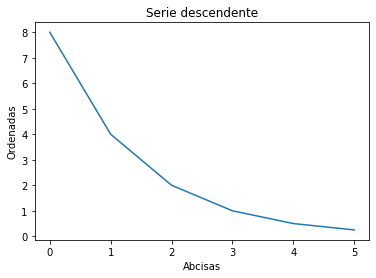

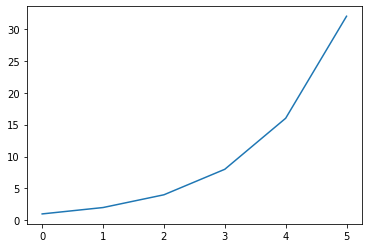

In [353]:
# Pruebas de funcionamiento:

representar_xxx_yyy([(1, 8), (2, 4), (3, 2), (4, 1), (5, 0.5), (6, 0.25)], ["Serie descendente", "Ordenadas", "Abcisas"])

representar_xxx_yyy([(1, 1), (2, 2), (3, 4), (4, 8), (5, 16), (6, 32)])

Salida esperada:

<img src='images/graph_01.png' width='800px' alt='Salida esperada del gráfico anterior: curva descentente y curva ascendente' />

### Una gráfica concreta

Deseamos representar el número de películas de nuestra base de datos que se han producido en un intervalo de años dado.

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

repr_movies_years(main_dict_data, 2000, 2010)
repr_movies_years(main_dict_data, 2005, 2015)

Salida esperada:

<img src='images/graph_02.png' width='800px' alt='' />

# D. Acceso a las urls de imdb y webscraping [2 puntos]

### D.1. Recuperación de las URLs

Con sencillas instrucciones, deseamos recuperar todas las *urls* de las películas de nuestro archivo, mostrando cuántas son, la primera de ellas o las diez primeras por ejemplo:

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

print(len(urls))

print()

print(first_url_movie)

print()

print(first_ten_urls)

Salida esperada:

    4919
    
    http://www.imdb.com/title/tt0499549/
    
    ['http://www.imdb.com/title/tt0499549/', 'http://www.imdb.com/title/tt0449088/', 'http://www.imdb.com/title/tt2379713/', 'http://www.imdb.com/title/tt1345836/', 'http://www.imdb.com/title/tt5289954/', 'http://www.imdb.com/title/tt0401729/', 'http://www.imdb.com/title/tt0413300/', 'http://www.imdb.com/title/tt0398286/', 'http://www.imdb.com/title/tt2395427/', 'http://www.imdb.com/title/tt0417741/']    

### D.2. Carga de la estructura sintáctica de una URL

Ahora, deseamos extraer el código `html` de una película.

In [ ]:
# Una forma de evitar el error "Requests 403 forbidden" al hacer web scraping en las siguientes celdas:

HEADERS = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:98.0) Gecko/20100101 Firefox/98.0",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.5",
        "Accept-Encoding": "gzip, deflate",
        "Connection": "keep-alive",
        "Upgrade-Insecure-Requests": "1",
        "Sec-Fetch-Dest": "document",
        "Sec-Fetch-Mode": "navigate",
        "Sec-Fetch-Site": "none",
        "Sec-Fetch-User": "?1",
        "Cache-Control": "max-age=0",
    }

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

soup = soup_movie(first_url_movie)

print(str(soup)[:1000])
print()
print("... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ...")
print()
print(str(soup)[-1000:])

Salida esperada:

    <!DOCTYPE html>
    <html lang="en-US" translate="no" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/"><head><meta charset="utf-8"/><meta content="width=device-width" name="viewport"/><script>if(typeof uet === 'function'){ uet('bb', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => {
            if (typeof window.csa !== 'undefined' && typeof window.csa === 'function') {
                var csaLatencyPlugin = window.csa('Content', {
                    element: {
                        slotId: 'LoadTitle',
                        type: 'service-call'
                    }
                });
                csaLatencyPlugin('mark', 'clickToBodyBegin', 1738853581913);
            }
        })</script><title>Avatar (2009) - IMDb</title><meta content="Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following hi
    
    ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ...
    
    g(e+c);return!!e}function n(){for(var e=RegExp("^https://(.*\.(images|ssl-images|media)-amazon\.com|"+c.location.hostname+")/images/","i"),d={},h=0,k=c.performance.getEntriesByType("resource"),l=!1,b,a,m,f=0;f<k.length;f++)if(a=k[f],0<a.transferSize&&a.transferSize>=a.encodedBodySize&&(b=e.exec(String(a.name)))&&3===b.length){a:{b=a.serverTiming||[];for(a=0;a<b.length;a++)if("provider"===b[a].name){b=b[a].description;break a}b=void 0}b&&(l||(l=g(b,"_cdn_fr")),
    a=d[b]=(d[b]||0)+1,a>h&&(m=b,h=a))}g(m,"_cdn_mp")}d.ue&&"function"===typeof d.ue.tag&&c.performance&&c.location&&n()},"cdnTagging")(ue_csm,window);
    
    
    }
    
    /* ◬ */
    </script>
    </div>
    <noscript>
    <img alt="" height="1" src="//fls-na.amazon.com/1/batch/1/OP/A1EVAM02EL8SFB:130-1575513-7998461:SMWGHB497V5D4NRH3FAY$uedata=s:%2Fuedata%2Fuedata%3Fnoscript%26id%3DSMWGHB497V5D4NRH3FAY:0" style="display:none;visibility:hidden;" width="1"/>
    </noscript>
    <script>window.ue && ue.count && ue.count('CSMLibrarySize', 61663)</script></div></body></html>

### D.3. Extracción de algunas piezas de información de una URL

Y ahora, con dicho código, deseamos extraer la siguiente información, referida a la película `first_url_movie`:

- La etiqueta completa del título de la película
- La descripción (sólo el contenido).
- La lista de actores
- La información sobre el presupuesto

In [ ]:
# Esta celda debe ser completada por el estudiante



Salida esperada:

    <title>Avatar (2009) - IMDb</title>
    
    Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and protecting the world he feels is his home.
    
    ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Michelle Rodriguez', 'Stephen Lang', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Dileep Rao', 'Matt Gerald', 'Sean Anthony Moran', 'Jason Whyte', 'Scott Lawrence', 'Kelly Kilgour', 'James Patrick Pitt', 'Sean Patrick Murphy']
    
    $237,000,000 (estimated)

### D.4. Actores que intervienen en una lista de URLs

Necesitamos crear un archivo con los actores de las películas de IMDB, dada la lista de sus URLs.

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

# OJO: esta operación puede llevar bastante tiempo.
# Para esta prueba, usamos un número limitado de películas.

gather_actors("actors_3_first_movies.txt", urls[:3])

with open("actors_3_first_movies.txt") as f:
    for _ in range(10):
        line = f.readline().strip()
        print(line)

Salida esperada:

    Sam Worthington
    Zoe Saldana
    Sigourney Weaver
    Michelle Rodriguez
    Stephen Lang
    Giovanni Ribisi
    Joel David Moore
    CCH Pounder
    Wes Studi
    Laz Alonso

In [ ]:
# La siguente llamada llevaría un tiempo realmente largo:

# import time # para cronometrar esta función, que tarda mucho

# reloj_inicio = time.time()
# gather_actors("actors_all_movies.txt", urls)
# reloj_fin = time.time()

# print("Tiempo invertido: %s segundos." % (reloj_fin - reloj_inicio))

# E. Pandas [2 puntos]

### E.1. El primer paso es la carga del archivo en un dataframe

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de funcionamiento

tabla_completa = load_dataframe(MOVIES_DATA)

tabla_completa

Salida esperada:

<img src='images/df_01.png' width='800px' alt='' />

### E.2. Tabla de los campos principales

A pertir de la tabla anterior, construimos otra con sólo algumos de los campos:

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# test de comprobación

tabla_breve = fields_selected_dataframe(tabla_completa)

tabla_breve

Salida esperada:

<img src='images/df_02.png' width='800px' alt='' />

### E.3. Columnas de una tabla

¿Cuáles son las columnas de nuestrsa `tabla_breve`?

In [ ]:
# Esta celda debe ser completada por el estudiante



Salida esperada:

    Index(['movie_title', 'color', 'director_name', 'language', 'country',
           'actor_1_name', 'movie_imdb_link'],
          dtype='object')

### E.4. Campos missing

Algunos campos muestran un valod `NaN`. Deseamos cambiarlo por una cadena de caracteres: `"Desc"`.

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de comprobación

tabla_breve

Salida esperada:

<img src='images/df_03.png' width='800px' alt='' />

### E.5. Director $\rightarrow$ películas y número de películas

Función que averigua la lista de títulos de películas de un director dado:

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# Test de comprobación:

tabla_tits = titulos_de_director_df(tabla_breve, "James Cameron")
tabla_tits

Salida esperada:

<img src='images/df_04.png' width='800px' alt='' />

In [ ]:
list_tits = tabla_tits["movie_title"].to_list()
print(list_tits)

Salida esperada:

    ['Avatar\xa0', 'Titanic\xa0', 'Terminator 2: Judgment Day\xa0', 'True Lies\xa0', 'The Abyss\xa0', 'Aliens\xa0', 'The Terminator\xa0']

¿Qué directores han dirigido más de *n* películas?

In [ ]:
# Esta celda debe ser completada por el estudiante



In [ ]:
# test de comprobación:

directors_max_movies_df(tabla_breve)

Salida esperada:

    (['Steven Spielberg'], np.int64(26))

# Parte F. Un cálculo masivo con map-reduce [0,5 puntos]

En este apartado se ha de realizar un programa aparte, *basado en la técnica de map-reduce*, que calcule, para cada idioma, en qué países en que se han producido películas y la suma de los presupuestos de dichas películas. Cuando el idioma o el país o el presupuesto no se conozcan, no se considerará esta película.

    C:\...> python language_budget_countries.py -q algunos_campos.txt

El programa funcionará necesariamente con la técnica map-reduce, que podemos poner en juego con la librería `mrjob`.

El funcionamiento del mismo se puede activar también desde aquí:

In [ ]:
# Hagamos una llamada al programa de consola desde aquí:

! python language_budget_countries.py -q algunos_campos.txt

In [ ]:
# Para que el resultado se almacene en un archivo:

! python language_budget_countries.py -q algunos_campos.txt > language_countries_budgets.txt

Para que pueda yo ver tu programa cómodamente desde aquí, también se puede mostrar con un comando de la consola, anteponiendo el símbolo `!`. Observaciones:

- La instrucción siguiente está comentada para ocultar una solución mía.
  Tú debes suprimir el símbolo `#` del comentario
  para mostrar tu solución aquí.
- Desde mac o linux, se ha de usar el comando `cat`, en vez de `type`.

In [ ]:
# ! type language_budget_countries.py

# Parte G. Un apartado libre [0.5 puntos]

<br>

<font color="green">
Dejo este apartado a tu voluntad. Inventa tú mismo el enunciado y resuélvelo, mostrando algún aspecto de programación en Python no contemplado o alguna técnica o librería que no has puesto en juego en los apartados anteriores, <b>relacionado con el análisis de datos y con el tema de este proyecto</b>. He aquí dos o tres ejemplos posibles:

- Me he quedado un poco insatisfecho con el uso de pandas, que encuentro un poco escaso:
  este apartado puede poner en juego algunas algunas operaciones que no hemos visto
  en esta librería.
  
- El acabado de las figuras es algo rudimentario.
  en cambio, la librería Plotly me permite permitirte trazar figuras más
  profesionales, y una posibilidad sencilla es quizá
  importar los datos del archivo creado por el programa de map-reduce
  y representarlos gráficamente.
  
- La disponibilidad de datos de geolocalización puede permitirte alguna representación
  de la ubicación de los vehísulos registrados en su posición geográfica.
  
Estos ejemplos pueden servirte como pista, pero que no te limiten. Hay muchas otras posibilidades: geopandas, web scraping, etc.

En la evaluación, si este apartado está bien o muy bien, anota un 0,3 o 0,4. El 0,5 lo reservaremos para las situaciones en que se presente algo brillante, con alguna idea original o alguna técnica novedosa o complejidad especial o algún gráfico vistoso. Especialmente quien opta a un 9,5 o más, debe esmerarse en plantear este apartado a la altura de esa calificación.
</font>

<br>

<font color="darkblue">
Tras eliminar el párrafo anterior, en verde, completa tú aquí este enunciado, cuya fuetne aparecerá en azul oscuro.
</font>

In [ ]:
# Este apartado debe ser completado por el estudiante



In [ ]:
# Pruebas de funcionamiento, también tarea del estudiante:



# Datos personales

<br>

<font color="darkblue">

-   **Apellidos:** ......................................
-   **Nombre:** ......................................
-   **Email:** ......................................
-   **Fecha:** ......................................

<br>

<font color="black">
    
### Ficha de autoevaluación

<br>

<font color="green">
Aquí vienen comentarios del estudiante. Lo siguiente es un ejemplo posible obviamente ... elimina este párrafo y redacta el tuyo propio, en azul.
</font>

<br>

<font color="darkblue">
    
|Apartado|Calificación|Comentario|
|-|-|-|
|a)  |2.0  / 2.5  |Completamente resuelto |
|b)  |0.0  / 2.0  |No lo he conseguido |
|c)  |0.0  / 1.5  |No he entendido el enunciado |
|d)  |0.25 / 1.0  |Sólo he conseguido una parte mínima |
|e)  |0.0  / 2.0  |No lo he conseguido |
|f)  |0.5  / 0.5  |No lo he conseguido más que mínimamente |
|g)  |0.0  / 0.5  |No he logrado el correcto funcionamiento |
|**Total** |**2.75** / 10.0|**Suspenso**|
</font>

<br>

<font color="black">
   
### Ayuda recibida y fuentes utilizadas
<li> https://www.codigopiton.com/obtener-columna-de-matriz-en-python/ </li>
<li> https://www.geeksforgeeks.org/python-get-unique-values-list/</li>
<li>https://docs.python.org/es/3.13/tutorial/datastructures.html</li>
<li>https://www.geeksforgeeks.org/python-get-unique-values-list/<li>

</font>

<br>

<font color="green">
... comentarios del estudiante ...
Pon tú este párrafo con tus propias observaciones. Elimina este párrafo en verde.
</font>

<br>

<font color="black">
    
### Comentario adicional

</font>

<br>

<font color="green">
... Este apartado es optativo. Si lo completas, ponlo en azul; si no, suprímelo con su título.

<br>

In [ ]:
# Esta celda se ha de respetar: está aquí para comprobar el funcionamiento de algunas funciones por parte de tu profesor

import sys
modulenames = set(sys.modules) & set(globals())

if "mrjob" in modulenames:
    print("* En las librerías importadas, la siguiente no es necesaria\n" +
          "      from mrjob.job import MRJob\n" +
          "  porque no va a usarse en el cuaderno, sino en un programa externo. Debe omitirse aquí.\n")

from os.path import exists

if not exists("./images/"):
    print("* He echado de menos la carpeta 'images'.\n")

# ----------------------------------------------------------------------------

if not 'defaultdict' in set(globals()) and not 'collections' in modulenames:
    print("El uso de diccionarios por defecto es muy importante y te recomiendo que te familiarices con ellos.")

# ----------------------------------------------------------------------------

nombres = dir()

# Constantes: .....................

# print("----------------- Constantes")

const_names_asked = ["MOVIES_DATA", "FEW_FIELDS"]
for const_name in const_names_asked:
    if const_name not in nombres:
        print("La constante '" + const_name + "' no se ha definido.\n")

# Funciones: .....................

# print("----------------- Funciones")

name_funcs_asked = ["load_full_data", "main_data_from_item", "datatypes_arranged", "load_main_data",
                    "movies_anno_for_director", "directors_max_movies", "years_num_movies", "store_file",
                    "actor_directors", "print_collaborations_min", "representar_xxx_yyy", "gather_actors",
                    "load_dataframe", "titulos_de_director_df", "directors_max_movies_df"]

name_funcs_defined = [f for f in name_funcs_asked if f in nombres]

name_funcs_not_defined = [f for f in name_funcs_asked if f not in nombres]

def comentario(frase, nombres) -> str:
    if nombres != []:
        print(frase + ": " + ", ".join(nombres) + ".\n")

comentario("Las funciones siguientes no están definidas: ", name_funcs_not_defined)

# Variables: .....................

# print("----------------- Variables")

name_vars_asked = ["full_header", "list_of_enumerated_headers", "datos_avatar_2009", "datos_star_wars_7",
                   "colores", "pelis_victor", "main_header", "main_dict_data", "num_movies", "num_movies_sorted",
                   "num_collaborations", "first_url_movie", "first_ten_urls", "response", "soup", "actors",
                   "presupuesto_apartado", "presupuesto_importe", "importe_str",
                   "tabla_breve", "tabla_tits", "list_tits"]

name_vars_not_defined = [v for v in name_vars_asked if v not in nombres]

comentario("Las variables siguientes no están calculadas: ", name_vars_not_defined)
              
# ----------------------------------------------------------------------------

# Funciones definidas: .....................

# print("----------------- Funciones definidas. Semántica")

funcs_defined = [globals()[f_name] for f_name in name_funcs_defined]

# print(funcs_defined)

# print("..............................................................................")

no_docstrings = [f.__name__ for f in funcs_defined if f.__doc__ is None]
comentario("Las funciones siguientes no tienen el docstring estándar: " , no_docstrings)

# print("..............................................................................")

escasos_docstrings = [f.__name__ for f in funcs_defined if f.__doc__ is not None and len(f.__doc__.split("\n")) < 2]
comentario("El docstring de las funciones siguientes es insuficiente: ", escasos_docstrings)

# print("----------------- Funcs. open sin contexto")

import inspect

fs_open_close = [f for f in name_funcs_defined
                 if "= open" in inspect.getsource(globals()[f])
                 or "=open" in inspect.getsource(globals()[f])]

comentario("* El manejo de archivos es mejor con un contexto 'with ...' en lugar de con open-close. " +
           "V. funciones siguientes", fs_open_close)

# print("----------------- Funcs. with readlines()")

fs_with_readlines = [f for f in funcs_defined if "readlines" in inspect.getsource(f)]

comentario("* La instrucción 'readlines()' carga un archivo entero en la memoria principal. " +
           "Esto conlleva un gasto de memoria realmente grande, " +
           "innecesario cuando sólo interesa una línea, o cuando puede procesarse " +
           "línea a línea. " +
           "Las siguientes funciones contienen la instrucción 'readlines'", fs_with_readlines)

# ----------------------------------------------------------------------------

if not exists("./language_budget_countries.py"):
    print("* El programa de map-reduce no está hecho. Te recomiendo " +
          "fuertemente que inviertas algún tiempo en él, pues los conceptos " +
          "que trata son importantes en el mundo de la ciencia de datos.")